# Exploratory Data Analysis Exercise with Pandas and Matplotlib

In this exercise, you are responsible for devleoping a data pipeline to ingest and analyze multi-state streamflow records from CSV files in our Canvas Class. This exercise will directly assist with HW #1. Filepath for the data:

    files -> Data -> NWIS_Streaflow -> <STATE>

You will download the data from Canvas and load it into a folder you create called "streamflow_data". Once within the repo, you will load the data into this python notebook and perform exploratory data analysis. After performing data cleaning and time-series alignment with Pandas, you will transition develop Matplotlib visualizations. The core of the assignment emphasizes the Matplotlib philosophy, challenging you to use powerful operators to link, overlay, and explore discharge trends across Idaho, Utah, and Wyoming.

The [USGS NWIS Mapper](https://apps.usgs.gov/nwismapper/) provides interactive mapping to locate sites and repective metadata.

## Task 1: Select, download, and bring the data into your notebook session

Use the [USGS NWIS Mapper](https://apps.usgs.gov/nwismapper/) to locate one site below a reservoir,  one site in a headwater catchment, and one site near a rivers terminus to the Great Salt Lake. Using this siteid, find the site data in the Canvas NWIS_Streamflow data folder, download it to your computer, then upload it to this repo into a folder named "streamflow_data". In the code block below, load the data into a Pandas DataFrame and inspect it as we previously did in the Pandas exercises (.head(), .describe()). Write down what you notice. Remove any outliers NaN values, and -999.

In [60]:
#09217900 below reservoir, 09289500 in oweep catchment, 10141000 weber river terminus
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as mp
import matplotlib.dates as mdates

#this is the only way my paths worth on the chpc, please adjust your path accoridngly
reservoir = pd.read_csv("/uufs/chpc.utah.edu/common/home/u1600917/Hydroinformatics/CommunicatingData-Plotting/streamflow_data/09217900_1980_2020.csv")
reservoir = reservoir.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
reservoir["Datetime"] = pd.to_datetime(reservoir["Datetime"])

catchment = pd.read_csv("/uufs/chpc.utah.edu/common/home/u1600917/Hydroinformatics/CommunicatingData-Plotting/streamflow_data/09289500_1980_2020.csv")
catchment = catchment.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
catchment["Datetime"] = pd.to_datetime(catchment["Datetime"])

terminus = pd.read_csv("/uufs/chpc.utah.edu/common/home/u1600917/Hydroinformatics/CommunicatingData-Plotting/streamflow_data/10141000_1980_2020.csv")
terminus = terminus.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
terminus["Datetime"] = pd.to_datetime(terminus["Datetime"])

#print(reservoir.head(), catchment.head(),terminus.head(),sep='\n') #Notes, reservoir doesn't start until 1982
#print(reservoir.describe(), catchment.describe(),terminus.describe(),sep='\n') #Notes, terminus has the most data,max. Also, reservoir has higher max than catchment, min is from reservoir

## Task 2: Slicing and Dicing

We are interested in examining the data from 2000-2010. Slice the data accordingly and save it to a new Pandas DataFrame.

In [ ]:
reservoir_2000_10 = reservoir.loc[reservoir.index[reservoir["Datetime"].dt.year == 2000].min():reservoir.index[reservoir["Datetime"].dt.year == 2010].max()]
reservoir_2000_10.set_index("Datetime",inplace=True)

catchment_2000_10 = catchment.loc[catchment.index[catchment["Datetime"].dt.year == 2000].min():catchment.index[catchment["Datetime"].dt.year == 2010].max()]
catchment_2000_10.set_index("Datetime",inplace=True)

terminus_2000_10 = terminus.loc[terminus.index[terminus["Datetime"].dt.year == 2000].min():terminus.index[terminus["Datetime"].dt.year == 2010].max()]
terminus_2000_10.set_index("Datetime",inplace=True)

## Task 3: Create plots for each DataFrame using the df.plot() function

Use the built in functionality of Pandas to plot the time series of each stream.

<Axes: title={'center': 'Headwaters Catchment Timeseries Streamflow Data'}, xlabel='Datetime', ylabel='Streamflow (cfs)'>

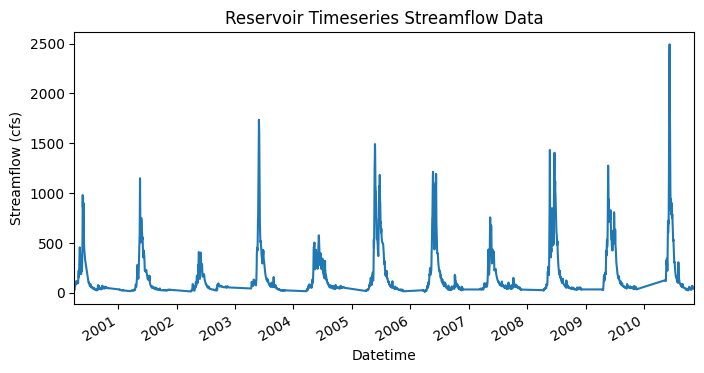

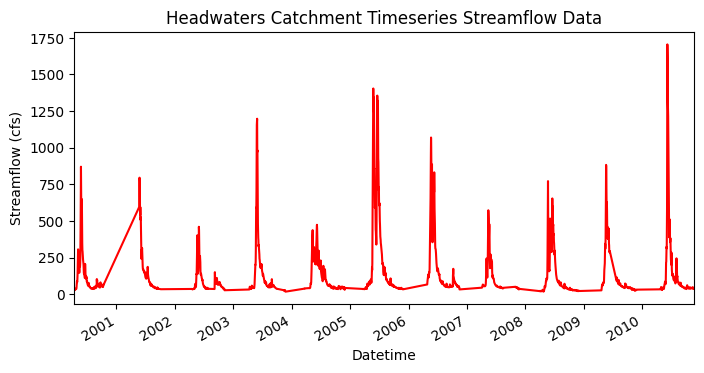

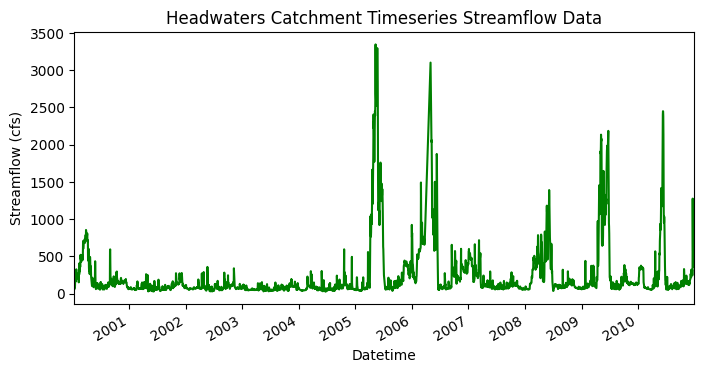

In [78]:
#Because we are plotting individually, legend isn't very helpful and it the way
reservoir_2000_10.plot(title="Reservoir Timeseries Streamflow Data",
                figsize = (8,4),
                ylabel="Streamflow (cfs)",
                xlim = (reservoir_2000_10.index.min(),reservoir_2000_10.index.max()),
                legend = False
                )

catchment_2000_10.plot(title="Headwaters Catchment Timeseries Streamflow Data",
                figsize = (8,4),
                ylabel="Streamflow (cfs)",
                xlim = (catchment_2000_10.index.min(),catchment_2000_10.index.max()),
                color='red',
                legend = False
                )

terminus_2000_10.plot(title="Headwaters Catchment Timeseries Streamflow Data",
                figsize = (8,4),
                ylabel="Streamflow (cfs)",
                xlim = (terminus_2000_10.index.min(),terminus_2000_10.index.max()),
                color='green',
                legend = False
                )

## Task 4: Join/Merge Pandas DataFrames

Create a single dataframe named All_Streams and combine all streamflow monitoring data into this dataframe. Hint, set your index to the date. Create custom labels for each monitoring station location to communicate there location within the watershed (e.g, headwater, below reservoir, GSL Terminus). Print the dataframe.head() to demonstrate that is complete.

In [63]:
streamflow = reservoir.merge(catchment.merge(terminus,how="outer",on="Datetime",sort=True,suffixes = ['_c','_t']),how="outer",on="Datetime",sort=True)
streamflow = streamflow.rename(columns={"USGS_flow_c":"Catchment Flow", "USGS_flow_t":"Terminus Flow","USGS_flow":"Reservoir Flow"})


## Task 5: Demonstrate your Prowess with Matplotlib

Create a Four separate figures with all three stream on them:

* Figure 1 should be a single plot with all three stream  monitoring locations
* Figure 2 should be a single figure with subplots for each stream monitoring location. The subplots should be 2 rows and 2 columns
* Figure 3 should be a single figure with subplots for each stream monitoring location. The subplots should be 3 rows and 1 column 
* Figure 3 should be a single figure with subplots for each stream monitoring location. The subplots should be 1 row and 3 columns

Make sure your plots have the correct axes, labeled axes, a title, a legend. Create custom labels for each monitoring station location to communicate there location within the watershed (e.g, headwater, below reservoir, GSL Terminus).